In [42]:
import pandas as pd
import numpy as np
import yfinance as yf
from tqdm import tqdm
from pathlib import Path



In [43]:


data_folder = Path("../../../data/raw/project_04_universe")



all_dfs = []

for file in data_folder.glob("*.csv"):
    
    df = pd.read_csv(file)
    
    ticker = file.stem.replace(".us","").upper()
    
    df["Ticker"] = ticker
    
    df["Date"] = pd.to_datetime(df["Date"])
    
    all_dfs.append(df)

prices = pd.concat(all_dfs, ignore_index=True)

prices.head()


,Date,Open,High,Low,Close,Volume,Ticker
0,1984-09-07,0.099265,0.100484,0.098067,0.099265,99149603.0,AAPL_US_D
1,1984-09-10,0.099265,0.099570,0.096879,0.098676,76956267.0,AAPL_US_D
2,1984-09-11,0.099570,0.102271,0.099570,0.100484,181467446.0,AAPL_US_D
3,1984-09-12,0.100484,0.101071,0.097458,0.097458,158527291.0,AAPL_US_D
4,1984-09-13,0.102880,0.103173,0.102880,0.102880,246900394.0,AAPL_US_D


In [44]:
prices["Ticker"] = prices["Ticker"].str.replace("_US_D", "", regex=False)

prices.head()


,Date,Open,High,Low,Close,Volume,Ticker
0,1984-09-07,0.099265,0.100484,0.098067,0.099265,99149603.0,AAPL
1,1984-09-10,0.099265,0.099570,0.096879,0.098676,76956267.0,AAPL
2,1984-09-11,0.099570,0.102271,0.099570,0.100484,181467446.0,AAPL
3,1984-09-12,0.100484,0.101071,0.097458,0.097458,158527291.0,AAPL
4,1984-09-13,0.102880,0.103173,0.102880,0.102880,246900394.0,AAPL


In [45]:
prices = prices.sort_values(["Ticker", "Date"]).reset_index(drop=True)

prices["fwd_ret_5"] = (
    prices.groupby("Ticker")["Close"]
    .shift(-5) / prices["Close"] - 1
)

df_target = prices.dropna().reset_index(drop=True)

df_target.head()



,Date,Open,High,Low,Close,Volume,Ticker,fwd_ret_5
0,1984-09-07,0.099265,0.100484,0.098067,0.099265,99149603.0,AAPL,0.051354
1,1984-09-10,0.099265,0.099570,0.096879,0.098676,76956267.0,AAPL,0.085097
2,1984-09-11,0.099570,0.102271,0.099570,0.100484,181467446.0,AAPL,0.026760
3,1984-09-12,0.100484,0.101071,0.097458,0.097458,158527291.0,AAPL,0.037071
4,1984-09-13,0.102880,0.103173,0.102880,0.102880,246900394.0,AAPL,-0.014697


In [46]:
df_target = prices[["Date","Ticker","Close","Volume","fwd_ret_5"]]

df_target = df_target.dropna().reset_index(drop=True)

df_target.head()



,Date,Ticker,Close,Volume,fwd_ret_5
0,1984-09-07,AAPL,0.099265,99149603.0,0.051354
1,1984-09-10,AAPL,0.098676,76956267.0,0.085097
2,1984-09-11,AAPL,0.100484,181467446.0,0.026760
3,1984-09-12,AAPL,0.097458,158527291.0,0.037071
4,1984-09-13,AAPL,0.102880,246900394.0,-0.014697


In [47]:
df_target.shape



(201037, 5)

In [48]:
df_target["Ticker"].nunique()

20

In [49]:
df_target["Date"].min(), df_target["Date"].max()


(Timestamp('1970-01-02 00:00:00'), Timestamp('2026-03-06 00:00:00'))

In [50]:
df_target = df_target[df_target["Date"] > "1985-01-01"]


In [51]:
df_target["Date"].min(), df_target["Date"].max()


(Timestamp('1985-01-02 00:00:00'), Timestamp('2026-03-06 00:00:00'))

In [52]:
df_target["fwd_ret_5"].describe()


count    176501.000000
mean          0.004226
std           0.048252
min          -0.587736
25%          -0.018565
50%           0.003607
75%           0.025880
max           1.555256
Name: fwd_ret_5, dtype: float64

In [53]:
from pathlib import Path

processed_folder = Path("../../../data/processed")

processed_folder.mkdir(parents=True, exist_ok=True)

print("Folder created:", processed_folder.resolve())


Folder created: C:\Users\rawls.varghese\quant-lab\data\processed


In [54]:
df_target.to_csv("../../../data/processed/project_04_target_returns.csv", index=False)


**Ticker Level Diagnostic**

In [55]:
ticker_summary = (
    df_target.groupby("Ticker")["fwd_ret_5"]
    .agg(["count", "mean", "std"])
)

ticker_summary = ticker_summary[ticker_summary["count"] >= 200]
ticker_summary["mean_over_std"] = ticker_summary["mean"] / ticker_summary["std"]
ticker_summary = ticker_summary.sort_values("mean_over_std", ascending=False)

ticker_summary.head(20)

,count,mean,std,mean_over_std
Ticker,,,,
TSLA,3946,0.010477,0.082428,0.127106
GOOGL,5421,0.005279,0.042299,0.124793
MSFT,10071,0.005326,0.044977,0.118407
NVDA,6821,0.009726,0.085308,0.114009
AMZN,7241,0.008402,0.078360,0.107219
META,3469,0.005738,0.054352,0.105577
JNJ,10373,0.002999,0.028951,0.103585
UNH,9052,0.005217,0.050454,0.103402
WMT,10372,0.003549,0.034823,0.101926


In [57]:
ticker_counts = df_target["Ticker"].value_counts()

ticker_counts.head(20)

Ticker
AAPL     10374
JNJ      10373
LLY      10373
PG       10373
HD       10372
JPM      10372
WMT      10372
XOM      10372
CVX      10371
PFE      10371
MSFT     10071
BAC      10017
COST      9991
UNH       9052
AMZN      7241
NVDA      6821
GS        6749
GOOGL     5421
TSLA      3946
META      3469
Name: count, dtype: int64

In [56]:
df_target["fwd_ret_5"].describe()

count    176501.000000
mean          0.004226
std           0.048252
min          -0.587736
25%          -0.018565
50%           0.003607
75%           0.025880
max           1.555256
Name: fwd_ret_5, dtype: float64

In [58]:
df_target.sort_values(["Ticker","Date"]).head(20)

,Date,Ticker,Close,Volume,fwd_ret_5
80,1985-01-02,AAPL,0.104363,208755580.0,0.028784
81,1985-01-03,AAPL,0.106168,198405824.0,0.056448
82,1985-01-04,AAPL,0.106168,163462083.0,0.048028
83,1985-01-07,AAPL,0.105571,203527444.0,0.082238
84,1985-01-08,AAPL,0.104656,168050097.0,0.071711
85,1985-01-09,AAPL,0.107367,198539298.0,0.053350
86,1985-01-10,AAPL,0.112161,329938490.0,-0.064185
87,1985-01-11,AAPL,0.111267,244179562.0,-0.037693
88,1985-01-14,AAPL,0.114253,322042718.0,-0.041854
89,1985-01-15,AAPL,0.112161,315534158.0,0.002701


In [63]:
df_target.isna().sum()

Date         0
Ticker       0
Close        0
Volume       0
fwd_ret_5    0
dtype: int64

**Cross Sectional Dispersion**

In [ ]:
daily_dispersion = df_target.groupby("Date")["fwd_ret_5"].std()  # On each day, how different are stock returns fron each other
daily_dispersion.describe()

count    10373.000000
mean         0.037432
std          0.018927
min          0.006447
25%          0.025340
50%          0.032953
75%          0.043832
max          0.395597
Name: fwd_ret_5, dtype: float64

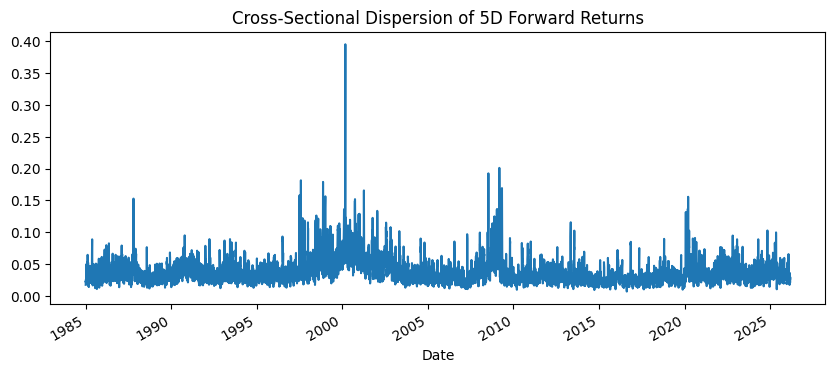

In [62]:
import matplotlib.pyplot as plt

daily_dispersion.plot(figsize=(10,4))
plt.title("Cross-Sectional Dispersion of 5D Forward Returns")
plt.show()

**Forward-return Leakage Sanity Check**

In [65]:
df_target["ret_1d"] = df_target.groupby("Ticker")["Close"].pct_change()
df_target[["ret_1d", "fwd_ret_5"]].corr()

,ret_1d,fwd_ret_5
ret_1d,1.000000,-0.029699
fwd_ret_5,-0.029699,1.000000
